In [19]:
import numpy as np
from synphot import SpectralElement
from synphot.models import Empirical1D
import os, glob
import emcee
import dust
import progressbar
import sys
import astropy.units as u
import astropy.constants as const
import traceback
import pickle
from astropy.io import fits, ascii
from astropy.stats import sigma_clipped_stats as scs
from scipy import interpolate
from scipy.integrate import simpson
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy.io.misc.hdf5 import read_table_hdf5
import pandas as pd
import itertools
from tqdm import tqdm
import corner
import time

In [20]:
nrc_filts = np.array(['F070W','F090W','F115W','F140M','F150W', 'F150W2', 'F162M',
                        'F164N','F182M','F187N','F200W','F210M','F212N','F250M',
                        'F277W','F300M','F322W2','F323N','F335M','F356W','F360M',
                        'F405N','F410M','F430M','F444W','F460M','F466N','F470N','F480M'])
wv_all = [float(i.replace('F', '').replace('W2', '').replace('M', '').replace('N', '').replace('W', ''))/100 
          for i in nrc_filts]

### RSG grid

In [ ]:
comp = 'sil'
bandpass_dir = os.environ['BANDPASS']

In [3]:
temps = np.array([2600.0, 2800.0, 3000.0, 3200.0, 3400.0, 3600.0, 3800.0, 4000.0, 4200.0, 4500.0, 4800.0, 5000.0])
dust_temps = np.array([500.0, 800.0, 1000.0, 1200.0, 1500.0])
taus = np.array([0.01, 0.325, 0.641, 0.956, 1.27, 1.59, 1.9, 2.22, 2.53, 2.85, 3.16, 3.48, 3.79,
                 4.11, 4.42, 4.74, 5.05, 5.37, 5.68, 6.0])
lums = np.logspace(3, 6, 16)
rv = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
av = np.arange(0.0, 5.5, 0.5)
len(temps), len(dust_temps), len(taus), len(lums), len(rv), len(av)

(12, 5, 20, 16, 6, 11)

In [5]:
full_grid = np.zeros((1497, len(temps), len(dust_temps), len(taus), len(lums), len(rv), len(av)))
mags = {}
for flt in nrc_filts:
    mags[flt] = np.zeros((len(temps), len(dust_temps), len(taus), len(lums), len(rv), len(av)))
len(full_grid.flatten())/1e6

1896.9984

In [6]:
spec = read_table_hdf5('data/r2/dusty_sil_grid/dusty_out/rsg_2600.0_500.0/rsg_2600.0_500.0.hdf5')
# spec = read_table_hdf5('data/r2/dusty_sil_grid/dusty_out/rsg_3000.0_800.0/rsg_3000.0_800.0.hdf5')

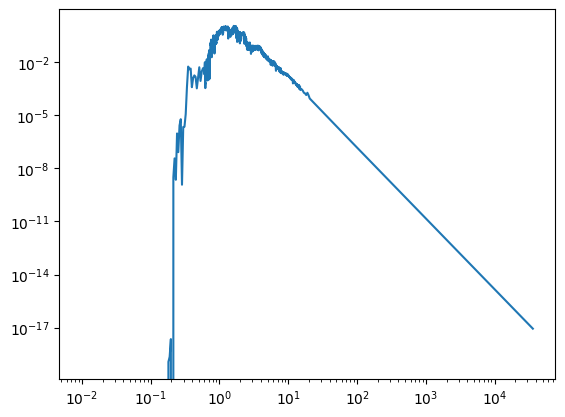

In [7]:
plt.plot(spec['lambda'], spec['flam_0.01'])
# plt.axvline(10)
plt.xscale('log')
plt.yscale('log')
# plt.ylim(1e-4, 1e-1)
# plt.xlim(5, 15)

In [10]:
with open(os.path.join('data', 'interpolate', 'rsg_s2.pkl'), 'rb') as f:
    models = pickle.load(f)

with open(os.path.join('data', 'interpolate', 'rsg_s2_test.pkl'), 'rb') as f:
    models_test = pickle.load(f)

In [11]:
tg, dtg, tug, lg = np.meshgrid(2800, 800, .01, 1e4, indexing='ij', sparse=True)
models['F070W']((tg, dtg, tug, lg)).flatten(), models_test['F070W']((tg, dtg, tug, lg)).flatten()

(array([27.93959705]), array([27.90953634]))

In [12]:
interp_val, interp_test = [], []
nrc_s = ['F070W', 'F090W', 'F115W', 'F150W', 'F200W', 'F250M', 'F277W', 'F356W', 'F444W']
wv_s = [float(i.split('F')[1].split('W')[0].split('M')[0]) for i in nrc_s]

wv_all = [float(i.replace('F', '').replace('W2', '').replace('M', '').replace('N', '').replace('W', ''))/100 
          for i in nrc_filts]
for f_ in nrc_filts:
    interp_val.append(models[f_]((tg, dtg, tug, lg)).flatten())
    interp_test.append(models_test[f_]((tg, dtg, tug, lg)).flatten())

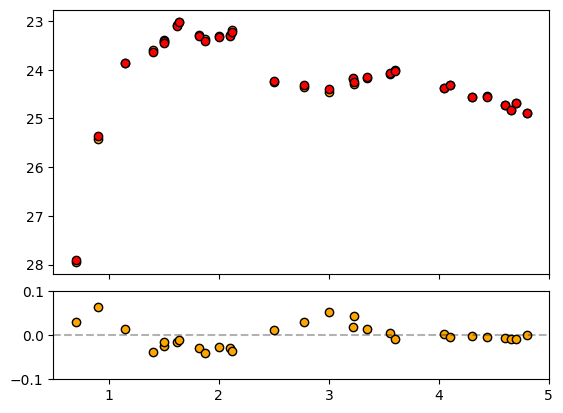

In [13]:
fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
ax1.scatter(wv_all, interp_val, fc='orange', ec='black')
ax1.scatter(wv_all, interp_test, fc='red', ec='black')
ax1.invert_yaxis()

ax2.scatter(wv_all, np.array(interp_val)-np.array(interp_test), fc='orange', ec='black')
ax2.axhline(0.0, ls='--', color='black', alpha=0.3)
ax2.set_ylim(-0.1, 0.1)

fig.subplots_adjust(hspace=0.1)

### mcmc

In [21]:
%reload_ext autoreload
%autoreload 2

from mcmc import mcmc
from mc_parallel import parallel_sed_fit

In [ ]:
sedfit = parallel_sed_fit(gal='ngc5643', 
                          photfile_path='data/dolphot/ngc5643', 
                          dm=30.57, 
                          dmerr=0.06, 
                          z=-0.25, 
                          trgb=('F090W', 26.20), 
                          keep_narrow=False, 
                          ncores=1)
rsgcat = sedfit.apply_initial_cuts()
# rsgcat.to_csv('data/dolphot/ngc5643/rsgcat_chimin.csv', index=False)

In [22]:
df_sil = pd.read_csv('data/dolphot/ngc5643/ngc5643_sil_rsgcat.csv')
df_grf = pd.read_csv('data/dolphot/ngc5643/ngc5643_grf_rsgcat.csv')
df_sil.set_index('index', inplace=True)
df_grf.set_index('index', inplace=True)

grfm = np.array([i in df_sil.index for i in df_grf.index])
silm = np.array([i in df_grf.index for i in df_sil.index])

df1 = df_sil[~silm]
df2 = df_grf[~grfm]
df3 = df_sil[silm][df_sil[silm]['chimin'].values < df_grf[grfm]['chimin'].values]
df4 = df_grf[grfm][df_sil[silm]['chimin'].values > df_grf[grfm]['chimin'].values]
rsgcat = pd.concat([df1, df2, df3, df4])

In [23]:
# rsgcat = pd.read_csv('data/dolphot/ngc5643/rsgcat_chimin.csv')
sedfit = parallel_sed_fit(gal='ngc5643', 
                          photfile_path='data/dolphot/ngc5643', 
                          dm=30.57, 
                          dmerr=0.06, 
                          z=-0.25, 
                          trgb=('F090W', 26.20), 
                          keep_narrow=False, 
                          ncores=1,
                          rsgcat=rsgcat)

In [123]:
keep_narrow = False
testcol = rsgcat[rsgcat['tau_chisq'] > 1].sample(1).iloc[0]

phot = {'mag': testcol[sedfit.cols['magcols']].values,
        'magerr': testcol[sedfit.cols['errcols']].values,
        'inst_filt': np.array(sedfit.cols['flts']),
        'index': f'ngc5643_{int(testcol['index'])}'}

if not keep_narrow:
        fl_mask = np.array(['N' in i for i in phot['inst_filt']]) | np.array(['300M' in i for i in phot['inst_filt']])
        phot['mag'] = phot['mag'][~fl_mask]
        
        phot['magerr'] = phot['magerr'][~fl_mask]
        phot['inst_filt'] = phot['inst_filt'][~fl_mask]

limmask = (phot['mag'] > 90.0) | (phot['magerr'] > 90.0) | (np.isnan(phot['mag'])) | (np.isnan(phot['magerr']))
phot['mag'] = phot['mag'][~limmask]
phot['magerr'] = np.sqrt(phot['magerr'][~limmask]**2 + 0.01**2)
phot['inst_filt'] = phot['inst_filt'][~limmask]

In [124]:
mc_obj = mcmc(dm=30.57, dmerr=0.06, z=-0.25, comp='sil', model_type='rsg')
mc_obj.verbose = True

fit_params = mc_obj.run_emcee(phot, nsteps=350, nwalkers=64, burn_in=75)
fit_pe = np.array(list(fit_params.values()))
reader = mc_obj.load_backend(phot)
sample = np.array(reader.get_chain(flat=True, discard=75, thin=1))
probs = np.array(reader.get_log_prob(flat=True, discard=75, thin=1))
min_chi_params = sample[np.argmax(probs)]

Backend file: data/backends/ngc5643_24404_rsg.h5
Backend name: 9317537468912733652782


100%|██████████| 350/350 [00:23<00:00, 15.00it/s]

Backend file: data/backends/ngc5643_24404_rsg.h5
Backend name: 9317537468912733652782
Current number of samples in backend: 22400
Minimum chi^2 is: 5.3379181



temperature       :     2703.689 + 156.31100000000015 - 63.68899999999985
dust_temp         :     1038.769 +      221.231 -      348.769
tau_V             :         2.16 +         0.61 -         0.62
luminosity        :    10630.297 + 3169.822933891338 - 1530.4169338913389
Rv                :         4.00 +         1.35 -         1.36
Av                :         1.33 +         0.95 -         0.85
Backend file: data/backends/ngc5643_24404_rsg.h5
Backend name: 9317537468912733652782


In [125]:
testcol[['teff_chisq', 'lum_chisq', 'tdust_chisq', 'tau_chisq', 'av_chisq', 'chimin']]

teff_chisq     2600.000000
lum_chisq      8214.427774
tdust_chisq    1200.000000
tau_chisq         2.500000
av_chisq          0.500000
chimin            0.010397
Name: 24404, dtype: float64

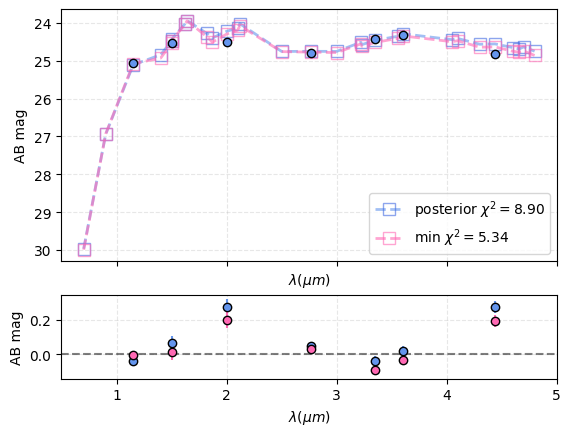

In [126]:
params = np.meshgrid(*fit_pe[:, 0], indexing='ij', sparse=True)
model_mag = np.array([mc_obj.model[f](params).flatten()[0] for f in phot['inst_filt']])+mc_obj.dm
chi1 = 0.5*np.sum((phot['mag'] - model_mag)**2 / phot['magerr']**2)/(len(model_mag)-1)
model_mag_plot = np.array([mc_obj.model[f](params).flatten()[0] for f in nrc_filts])+mc_obj.dm

mc_params = np.meshgrid(*min_chi_params, indexing='ij', sparse=True)
chi_mag = np.array([mc_obj.model[f](mc_params).flatten()[0] for f in phot['inst_filt']])+mc_obj.dm
chi2 = 0.5*np.sum((phot['mag'] - chi_mag)**2 / phot['magerr']**2)/(len(chi_mag)-1)
chi_mag_plot = np.array([mc_obj.model[f](mc_params).flatten()[0] for f in nrc_filts])+mc_obj.dm

fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
wv = np.array([float(i[1:4])/100 for i in phot['inst_filt']])
ax1.errorbar(x=wv, y=phot['mag'], yerr=phot['magerr'], linestyle='none', marker='o', markerfacecolor='cornflowerblue', 
             markeredgecolor='black', ecolor='cornflowerblue')
ax1.plot(wv_all, model_mag_plot, marker = 's', markerfacecolor = 'None', markeredgecolor = 'royalblue', 
         markersize = 8, ls='--', lw=2, alpha = 0.6, color='cornflowerblue', label = rf'posterior $\chi^2={chi1:.2f}$')
ax1.plot(wv_all, chi_mag_plot, marker = 's', markerfacecolor = 'None', markeredgecolor = 'hotpink', 
         markersize = 8, ls='--', lw=2, alpha = 0.6, color='hotpink', label = rf'min $\chi^2={chi2:.2f}$')
ax1.grid(alpha=0.3, linestyle='--')
ax1.invert_yaxis()
ax1.legend()
ax1.set_xlabel(r'$\lambda(\mu m)$')
ax1.set_ylabel('AB mag')

ax2.errorbar(wv, phot['mag'] - model_mag, yerr=phot['magerr'], linestyle='none', marker='o', markerfacecolor='cornflowerblue',
             markeredgecolor='black', ecolor='cornflowerblue', label = 'posterior sample')
ax2.errorbar(wv, phot['mag'] - chi_mag, yerr=phot['magerr'], linestyle='none', marker='o', markerfacecolor='hotpink',
             markeredgecolor='black', ecolor='hotpink', label = r'min $\chi^2$')
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_xlabel(r'$\lambda(\mu m)$')
ax2.set_ylabel('AB mag')
ax2.axhline(0.0, linestyle='--', alpha=0.5, color='black');
# plt.savefig(f'plots/rsg_mcmc_err{len(glob.glob('plots/rsg_mcmc_err*')) + 1}.png', bbox_inches='tight', dpi=500)
# plt.savefig('plots/rsg_mcmc14.png', bbox_inches='tight', dpi=500)

In [127]:
print('raw chi^2:', 0.5*np.sum((phot['mag'] - chi_mag)**2)/(len(chi_mag)-1))

raw chi^2: 0.007530325574236681


In [128]:
mc_params

(array([[[[[[2616.43639345]]]]]]),
 array([[[[[[1209.50738301]]]]]]),
 array([[[[[[2.16496145]]]]]]),
 array([[[[[[9474.84267652]]]]]]),
 array([[[[[[4.67451375]]]]]]),
 array([[[[[[0.99897859]]]]]]))

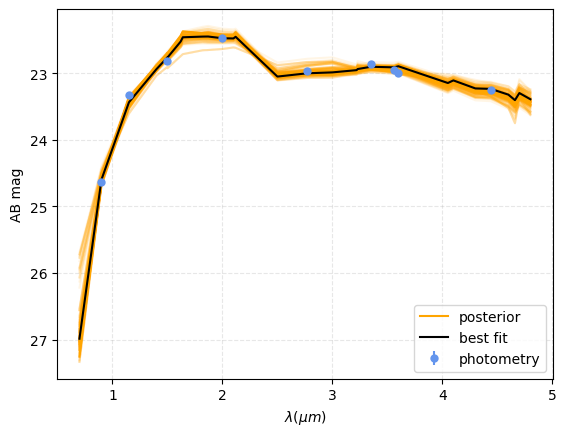

In [121]:
wv = np.array([float(i[1:4])/100 for i in phot['inst_filt']])
plt.errorbar(x=wv, y=phot['mag'], yerr=phot['magerr'], linestyle='none', marker='o', 
             markerfacecolor='cornflowerblue', markeredgecolor='none', ecolor='cornflowerblue', label='photometry')

wv_all = [float(i.replace('F', '').replace('W2', '').replace('M', '').replace('N', '').replace('W', ''))/100 
          for i in nrc_filts]

csm = sample#[5000:]
inds = np.random.randint(len(csm), size=200)

for i, idx in enumerate(inds):
    model_mag = np.array([mc_obj.model[f](csm[idx]).flatten()[0] for f in nrc_filts])+mc_obj.dm
    if i==0:
        plt.plot(wv_all, model_mag, alpha = 1.0, color='orange', label='posterior')
    else:
        plt.plot(wv_all, model_mag, alpha = 0.1, color='orange')

params = np.meshgrid(*fit_pe[:, 0], indexing='ij', sparse=True)

best_model_mag = np.array([mc_obj.model[f](params).flatten()[0] for f in nrc_filts])+mc_obj.dm
plt.plot(wv_all, best_model_mag, color='black', label='best fit')

plt.legend()
plt.xlabel(r'$\lambda(\mu m)$')
plt.ylabel('AB mag')
plt.grid(alpha=0.3, linestyle='--')
plt.gca().invert_yaxis()
# plt.savefig('plots/mc_default_move.png', bbox_inches='tight', dpi=500)

root [@ Wed, 03 Sep 2025 14:55:22] [l 718] - WARNING - Too few points to create valid contours
root [@ Wed, 03 Sep 2025 14:55:22] [l 718] - WARNING - Too few points to create valid contours
root [@ Wed, 03 Sep 2025 14:55:22] [l 718] - WARNING - Too few points to create valid contours


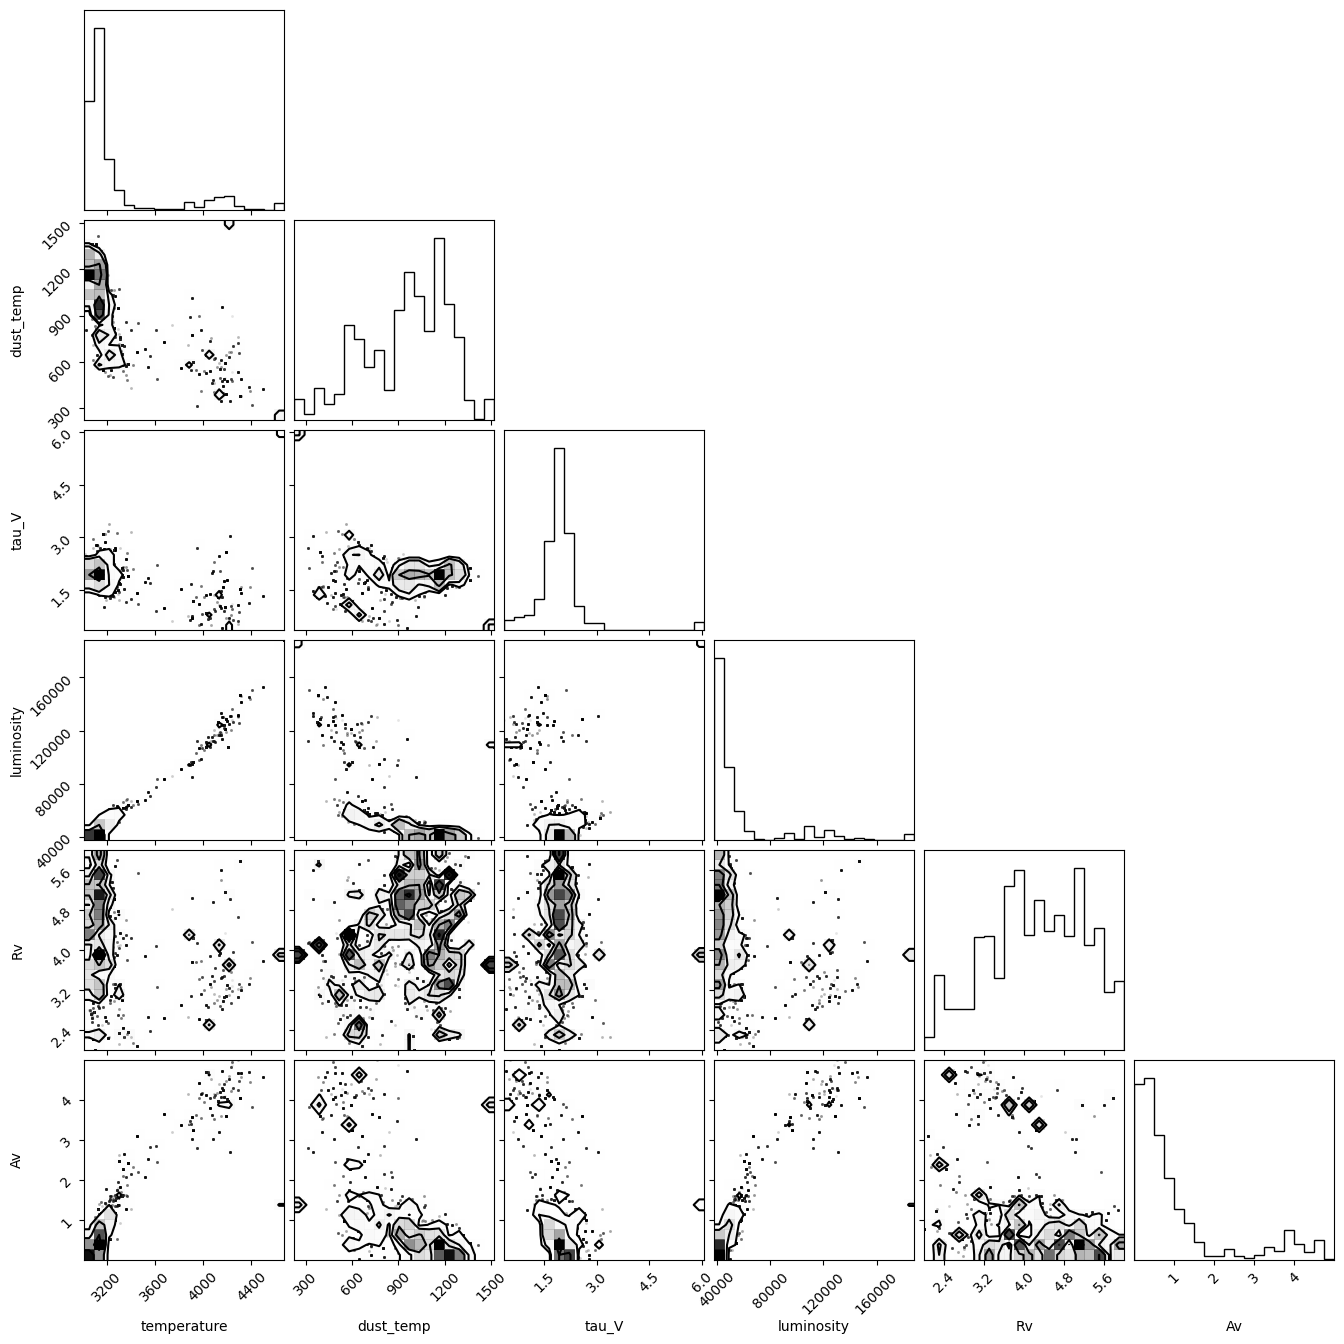

In [122]:
fig = corner.corner(
    sample, labels=mc_obj.model_fit_params[mc_obj.model_type],
    
);

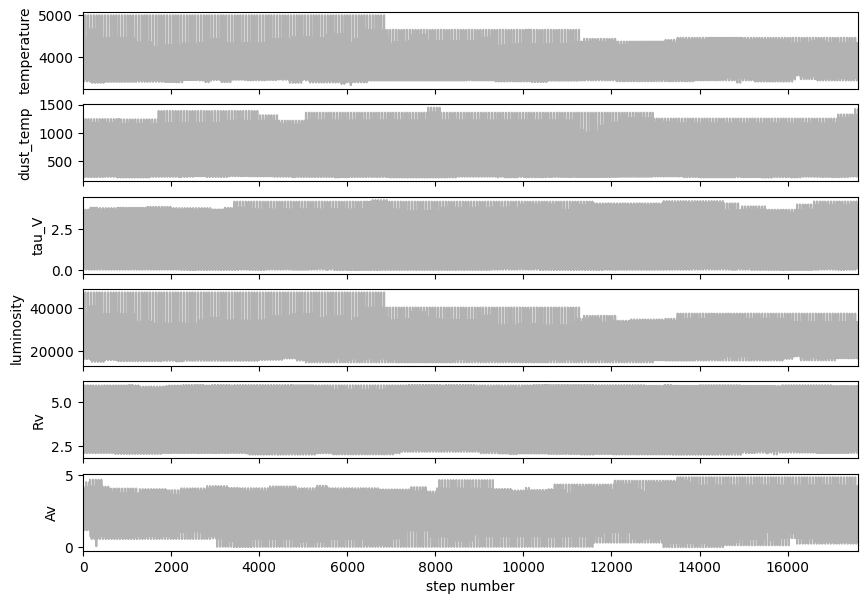

In [167]:
labels = mc_obj.model_fit_params[mc_obj.model_type]
fig, axes = plt.subplots(len(labels), figsize=(10, 7), sharex=True)
for i in range(len(labels)):
    ax = axes[i]
    ax.plot(sample[:, i], "k", alpha=0.3)
    ax.set_xlim(0, len(sample))
    ax.set_ylabel(labels[i])
    # ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

### base catalog

In [16]:
mc_obj = mcmc(dm=30.57, dmerr=0.06, z=-0.25)
mc_obj.verbose = True
mc_obj.bounds['luminosity'] = [10**3.5, 10**6.0]
mc_obj.bounds['temperature'] = [3500., 5000.]

sample_models = np.zeros((10000, len(nrc_filts)))
sample_params = mc_obj.get_init_pos(6, 10000)
sample_params = sample_params[sample_params[:, 0].argsort()]
for i, p_ in enumerate(sample_params):
    model_mag = np.array([mc_obj.model[f](sample_params[i]).flatten()[0] for f in nrc_filts]) + mc_obj.dm
    sample_models[i, :] = model_mag

In [17]:
mc_obj = mcmc(dm=30.57, dmerr=0.06, z=-0.25)
mc_obj.verbose = True
mc_obj.bounds['luminosity'] = [10**3.5, 10**3.6]

base_models = np.zeros((2000, len(nrc_filts)))
basedf_cols = [i+'_mag' for i in nrc_filts]

sample_params = mc_obj.get_init_pos(6, 1000)
for i, p_ in enumerate(sample_params):
    model_mag = np.array([mc_obj.model[f](sample_params[i]).flatten()[0] for f in nrc_filts]) + mc_obj.dm
    base_models[i, :] = model_mag


mc_obj.bounds['luminosity'] = [10**5.8, 10**6]
sample_params = mc_obj.get_init_pos(6, 1000)
for i, p_ in enumerate(sample_params):
    model_mag = np.array([mc_obj.model[f](sample_params[i]).flatten()[0] for f in nrc_filts]) + mc_obj.dm
    base_models[i+1000, :] = model_mag

min_model = np.max(base_models[base_models[:, 1] < 26.20], axis=0) #TRGB at F090W 26.20 mag for NGC5643
min_model_df = pd.DataFrame([dict(zip(basedf_cols, min_model))])

max_model = np.min(base_models[base_models[:, 1] < 26.20], axis=0)
max_model_df = pd.DataFrame([dict(zip(basedf_cols, max_model))])

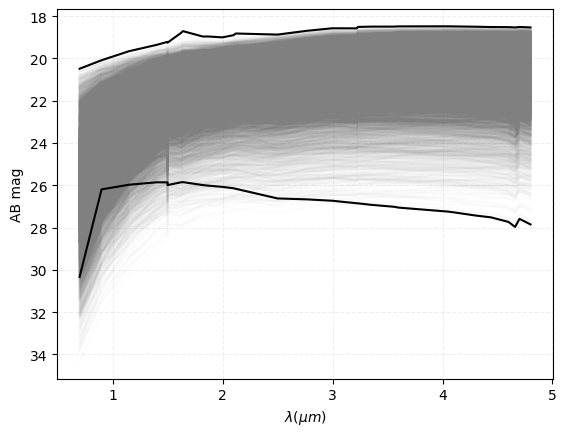

In [18]:
fig, ax = plt.subplots(1, 1)
for i, m_ in enumerate(sample_models):
    ax.plot(wv_all, m_, color='gray', alpha=0.02)
ax.plot(wv_all, min_model, color='black')
ax.plot(wv_all, max_model, color='black')
ax.invert_yaxis()
ax.grid(alpha=0.2, linestyle='--')
ax.set_xlabel(r'$\lambda(\mu m)$')
ax.set_ylabel('AB mag');

Text(0, 0.5, 'AB mag')

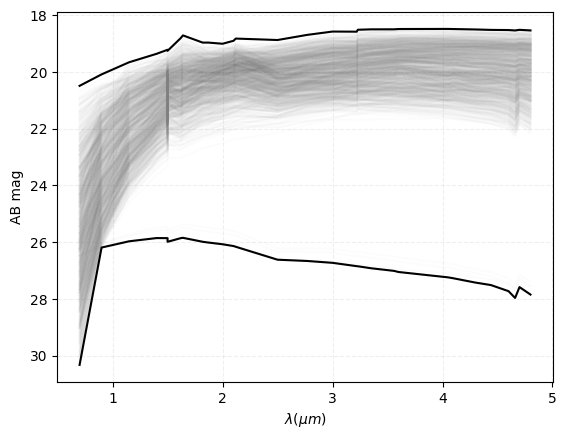

In [19]:
fig, ax = plt.subplots(1, 1)
for i, m_ in enumerate(base_models[base_models[:, 1] < 26.20]):
    ax.plot(wv_all, m_, color='gray', alpha=0.02)
ax.plot(wv_all, min_model, color='black')
ax.plot(wv_all, max_model, color='black')
ax.invert_yaxis()
ax.grid(alpha=0.2, linestyle='--')
ax.set_xlabel(r'$\lambda(\mu m)$')
ax.set_ylabel('AB mag')

In [48]:
def detmask(cat_mags_det, min_det=4):
    cat_wv = np.array([float(i[1:4])/100 for i in cat_mags_det.columns])

    opt_dets = cat_mags_det[cat_mags_det.columns[(cat_wv < 1.2)]]
    nir_dets = cat_mags_det[cat_mags_det.columns[(cat_wv > 1.2) & (cat_wv < 2.6)]]
    mir_dets = cat_mags_det[cat_mags_det.columns[(cat_wv > 2.6)]]

    ndetm = cat_mags_det.sum(axis=1) > min_det
    detm = (opt_dets.sum(axis=1) > 0) & (nir_dets.sum(axis=1) > 1) & (mir_dets.sum(axis=1) > 1) & ndetm

    return detm

def peakmask(cat_mags):
    cat_wv = np.array([float(i[1:4])/100 for i in cat_mags.columns])

    opt_dets = cat_mags[cat_mags.columns[(cat_wv < 1.2)]]
    nir_dets = cat_mags[cat_mags.columns[(cat_wv > 1.2) & (cat_wv < 2.6)]]
    mir_dets = cat_mags[cat_mags.columns[(cat_wv > 2.6)]]

    opt_peak, opt_med = opt_dets.min(axis=1), opt_dets.median(axis=1)
    nir_peak, nir_med = nir_dets.min(axis=1), nir_dets.median(axis=1)
    mir_peak, mir_med = mir_dets.min(axis=1), mir_dets.median(axis=1)

    req_nir_peak = (nir_peak < opt_peak) & (nir_peak < mir_peak)
    dust_peak = (nir_peak < opt_peak) & ((mir_med - opt_med) < -0.5) & ((nir_med - mir_med) < 1.0) & ((nir_med - mir_med) > 0)
    peakm = req_nir_peak | dust_peak
    print(req_nir_peak.sum(), dust_peak.sum())
    
    return peakm

def colormask(cat_mags, fls, sample_models, min_width=0.5, rel_err=0.25):
    cat_mags = cat_mags[fls]
    color_dict = {}
    cmb_iterator = list(itertools.combinations(nrc_filts, 2))
    idx_iterator = list(itertools.combinations(range(0, 29), 2))
    for i, j in zip(idx_iterator, cmb_iterator):
        f1, f2 = j[0], j[1]
        i1, i2 = i[0], i[1]
        index = f1+'_'+f2
        color_bounds = sample_models[:, i1] - sample_models[:, i2]
        cl_min = min(color_bounds) - rel_err #*np.abs(min(color_bounds))
        cl_max = max(color_bounds) + rel_err #*np.abs(max(color_bounds))
        cld = cl_max - cl_min
        if cld < min_width:
            cl_min = cl_min - (min_width - cld)/2
            cl_max = cl_max + (min_width - cld)/2
        color_dict[index] = (cl_min, cl_max)

    nwm = np.array(['N' in i for i in fls]) | np.array(['300M' in i for i in fls])
    mfls = fls[~nwm]

    colorm = np.array([True]*len(cat_mags))
    # colorm = np.zeros(len(cat_mags))
    for i, j in itertools.combinations(mfls, 2):
        idx_ = i.replace('_mag', '')+'_'+j.replace('_mag', '')
        cat_color = cat_mags[i] - cat_mags[j]
        dm = (cat_mags[i] > 90) | (cat_mags[j] > 90)
        colm_ = (cat_color > color_dict[idx_][0]) & (cat_color < color_dict[idx_][1])
        colm_ = colm_ | dm
        colorm = colorm & colm_
        # colorm = colorm + colm_.astype(int)
    # colorm = colorm > ((len(mfls)-1) * (len(mfls) - 2))/2 + 5
    return colorm, color_dict

fls = ['mag' in i for i in cat.columns]
fls = cat.columns[fls]
cat_mags = cat[fls]
cat_wv = np.array([float(i[1:4])/100 for i in cat_mags.columns])
cat_mags = cat_mags.replace(99.999, 0.5)
cat_mags = cat_mags.replace(np.nan, 0.5)

mindf = cat_mags-min_model_df[fls].to_numpy()
cat_mags = cat_mags.replace(0.5, 99.999)
maxdf = cat_mags-max_model_df[fls].to_numpy()
difm = (mindf < 0).all(axis=1) & (maxdf > 0).all(axis=1)
ndet = (cat_mags > 10) & (cat_mags < 38) 
ndetm = detmask(ndet)
base_mask = difm & ndetm  
rsgcat = cat[base_mask] #.replace(np.nan, 99.999)
print(len(rsgcat))

# f1, f2 = 'F115W', 'F200W'
# jkm = (rsgcat[f1+'_mag'] < 90) & (rsgcat[f2+'_mag'] < 90)
# cl, m = rsgcat[f1+'_mag'] - rsgcat[f2+'_mag'], rsgcat[f2+'_mag']
# # rsgmask = (m<26) & (m > lin(cl, -20.0, 33.0-3)) & (m < lin(cl, -8.0, 25+3.5))
# rsgmask = (m < 26) & (cl > 0.1) & jkm
# agbmask = (m < 26) & ((m > lin(cl, -10.0, 25+6)) | (m < lin(cl, -20.0, 33.0-5)))
# agbmask = agbmask & jkm
# rsgcat = rsgcat[rsgmask].replace(np.nan, 99.999)
# print(len(rsgcat))

# colorm, color_dict = colormask(rsgcat, fls, sample_models, min_width=0.2, rel_err=0.3)

# peakm = peakmask(rsgcat)
# rsgcat = rsgcat[colorm]
# print(len(rsgcat))
# rsgcat = rsgcat[~colorm][fls].replace(99.999, np.nan)

# f1, f2 = 'F115W', 'F200W'
# cl, m = rsgcat[f1+'_mag'] - rsgcat[f2+'_mag'], rsgcat[f2+'_mag']
# rsgmask = (m<26) & (m > lin(cl, -20.0, 33.0-3)) & (m < lin(cl, -8.0, 25+3.5))
# rsgcat = rsgcat[~rsgmask]

flts = [i.replace('_mag','') for i in fls]
magcols = [i+'_mag' for i in flts]
errcols = [i+'_err' for i in flts]

91730


In [260]:
min_width, rel_err = 1.0, 1.0

cat_mags = cat_mags[fls]
nwm = np.array(['N' in i for i in fls]) #| np.array(['M' in i for i in fls])
mfls = fls[~nwm]

colorm = np.array([True]*len(cat_mags))
for i, j in itertools.combinations(mfls, 2):
    idx_ = i.replace('_mag', '')+'_'+j.replace('_mag', '')
    cat_color = testcol[i] - testcol[j]
    dm = (testcol[i] > 90) | (testcol[j] > 90)
    colm_ = (cat_color > color_dict[idx_][0]) & (cat_color < color_dict[idx_][1])
    colm_ = colm_ | dm
    if not colm_:
        print(idx_, cat_color, color_dict[idx_], dm)
    colorm = colorm & colm_

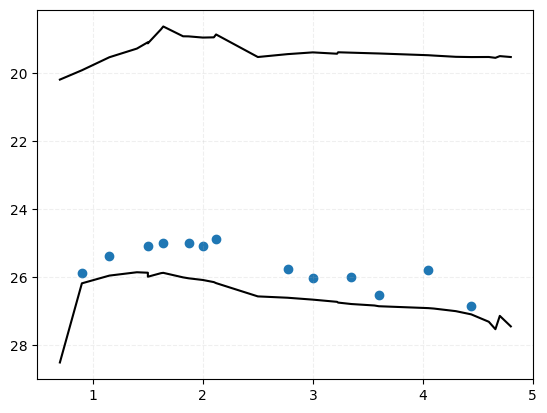

In [426]:
plt.scatter(cat_wv, rsgcat.sample(1).values[0])
plt.plot(wv_all, min_model, color='black')
plt.plot(wv_all, max_model, color='black')
plt.gca().invert_yaxis()
plt.grid(alpha=0.2, linestyle='--')

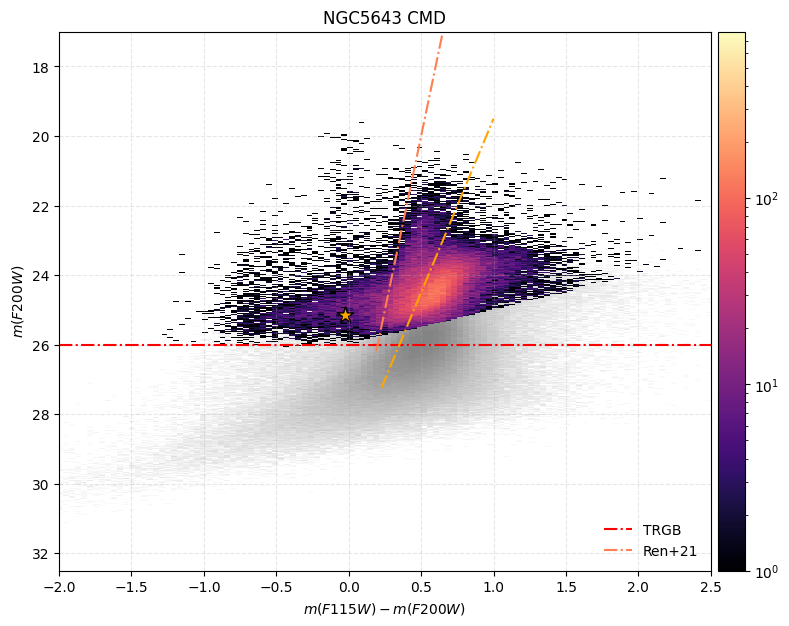

In [49]:
fig, ax = plt.subplots(1, 1, figsize = (10, 7))
f1, f2 = 'F115W', 'F200W'

cl, m = cat[f1+'_mag'] - cat[f2+'_mag'], cat[f2+'_mag']
rsg_cl, rsg_m = rsgcat[f1+'_mag'] - rsgcat[f2+'_mag'], rsgcat[f2+'_mag']

ax.hist2d(cl, m, bins = 4000, norm = 'log', cmap = 'Grays')
hist = ax.hist2d(rsg_cl, rsg_m, bins = 4000, norm = 'log', cmap = 'magma')

ax.axhline(26, color = 'red', label='TRGB', linestyle = '-.')
ax.plot(np.linspace(0.1905, 1, 100), lin(np.linspace(0.1905, 1, 100), -20.0, 33.0-3), linestyle='-.', color = 'coral', label = 'Ren+21')
ax.plot(np.linspace(0.22625, 1, 100), lin(np.linspace(0.22625, 1, 100), -10.0, 25+4.5), linestyle='-.', color = 'orange')
ax.scatter(phot['mag'][1] - phot['mag'][3], phot['mag'][3], marker='*', s=150, fc='orange', ec='black')

cbar = fig.colorbar(hist[3], ax = ax, pad = 0.009)
ax.set_xlabel(rf'$m({f1}) - m({f2})$')
ax.set_ylabel(rf'$m({f2})$')
ax.set_title('NGC5643 CMD')

ax.legend(loc = 'lower right', framealpha = 0)
ax.tick_params(axis='both', which='major')
ax.tick_params(axis='both', which='minor')
cbar.ax.tick_params() 
ax.grid(alpha = 0.3, linestyle = '--')
ax.set_xlim(-2, 2.5)
ax.set_ylim(32.5, 17)
plt.show()

In [25]:
phot

{'mag': array([23.324, 22.715, 22.343, 22.187, 22.814, 22.922, 22.996, 23.022,
        23.572]),
 'magerr': array([0.005, 0.007, 0.002, 0.004, 0.003, 0.009, 0.003, 0.01 , 0.013]),
 'inst_filt': array(['F090W', 'F115W', 'F150W', 'F200W', 'F277W', 'F335M', 'F356W',
        'F360M', 'F444W'], dtype='<U5'),
 'index': 'ngc5643_225399'}

In [26]:
teff_ = np.arange(2600, 5050, 50)
tdust_ = np.arange(200, 1800, 100)
tau_ = np.array(list(np.linspace(0.01, 2, 21)) + list(np.arange(2.5, 5.5, 0.5)))
Av_ = np.array(list(np.linspace(0, 1, 5))+ list(np.linspace(1.5, 3, 4)))
len(teff_) * len(tdust_) * len(tau_) * len(Av_)

190512

In [98]:
modeldf = pd.DataFrame(columns = ['Teff', 'Tdust', 'Tau', 'Av']+nrc_filts)
for a1 in tqdm(teff_):
    for a2 in tdust_:
        for a3 in tau_:
            for a4 in Av_:
                pm_ = [a1, a2, a3, 1e3, 3.1, a4]
                model_mag = np.array([mc_obj.model[f](pm_).flatten()[0] for f in nrc_filts]) + mc_obj.dm
                modeldf.loc[len(modeldf), ['Teff', 'Tdust', 'Tau', 'Av']+nrc_filts] = [a1, a2, a3, a4] + list(model_mag)
modeldf.to_csv('modeldf_ngc5643.csv', index=False)

100%|██████████| 49/49 [13:41<00:00, 16.76s/it]


In [50]:
modeldf = pd.read_csv('data/dolphot/ngc5643/ngc5643_modeldf.csv')

In [51]:
def chimin(phot, modeldf):
    modelmagval = modeldf[phot['inst_filt']].values
    submagval = modelmagval - phot['mag']
    meanval = np.average(submagval, weights = 1/phot['magerr']**2, axis=1)
    submagval = submagval - meanval[:, None]
    chisqe = np.sum(submagval**2/phot['magerr']**2, axis=1)/len(phot['mag'] - 1)
    chisq = np.sum(submagval**2, axis=1)/len(phot['mag'] - 1)
    minchisq = np.argmin(chisqe)

    # print(chisq[minchisq])
    # # otherbestmodel = modeldf.loc[55544][phot['inst_filt']].values - np.log10(21729/1e3)*2.5
    # otherbestmodel = chi_mag
    # photmag=phot['mag']
    # print(np.sum((otherbestmodel - photmag)**2)/(len(photmag) - 1))
    # print((otherbestmodel - photmag)**2)
    # print(submagval[minchisq]**2)

    bestparams = modeldf.loc[minchisq, ['Teff', 'Tdust', 'Tau', 'Av']].values
    pm_ = [bestparams[0], bestparams[1], bestparams[2], 1e3, 3.1, bestparams[3]]
    bestmodel = np.array([mc_obj.model[f](pm_).flatten()[0] for f in phot['inst_filt']]) + mc_obj.dm
    lum = 10**(np.mean((phot['mag'] - bestmodel)/-2.5)) * 1e3
    return chisq[minchisq], minchisq, lum, submagval[minchisq]

In [52]:
c_, m_, l_, res = chimin(phot, modeldf)
print(c_, l_)
print(modeldf.loc[m_, ['Teff', 'Tdust', 'Tau', 'Av']])

0.0020106036604985392 4364.36944970106
Teff     4050.0
Tdust    1700.0
Tau         2.0
Av          0.5
Name: 116579, dtype: float64


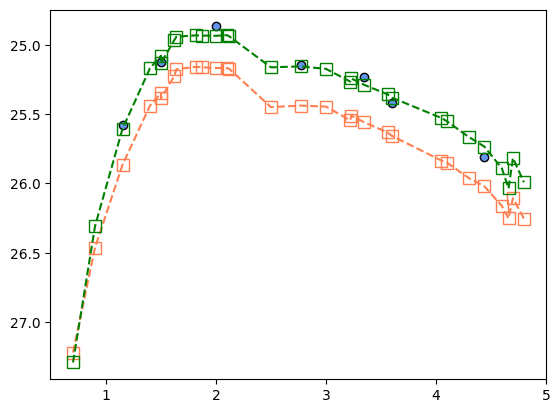

In [53]:
plt.plot(wv_all, modeldf.loc[m_][nrc_filts].values - np.log10(l_/1e3)*2.5, color='coral', ls='--', marker='s', markerfacecolor='none', markersize=8)
plt.plot(wv_all, chi_mag_plot, color='green', ls='--', marker='s', markerfacecolor='none', markersize=8)
# plt.plot(wv_all, modeldf.loc[17065][nrc_filts].values - np.log10(7479/1e3)*2.5, color='green', ls='--', marker='s', markerfacecolor='none', markersize=8)
plt.scatter(wv, phot['mag'], fc='cornflowerblue', ec='black')
# plt.scatter(wv_all, np.array([mc_obj.model[f]([3800, 1300, 0.1095, 56329, 3.1, 0.75]).flatten()[0] for f in nrc_filts]) + mc_obj.dm, color='blue')
plt.gca().invert_yaxis()

In [54]:
rescat = pd.DataFrame(columns=sedfit.cols['flts'])

In [55]:
keep_narrow = True
rsgcat[['chimin', 'teff', 'tdust', 'tau', 'av', 'lum']] = np.nan
for idx in tqdm(rsgcat.index):
    testcol = rsgcat.loc[idx]

    phot = {'mag': testcol[sedfit.cols['magcols']].values,
            'magerr': testcol[sedfit.cols['errcols']].values,
            'inst_filt': np.array(sedfit.cols['flts']),
            'index': f'ngc5643_{int(testcol['index'])}'}

    if not keep_narrow:
            fl_mask = np.array(['N' in i for i in phot['inst_filt']]) | np.array(['300M' in i for i in phot['inst_filt']])
            phot['mag'] = phot['mag'][~fl_mask]
            
            phot['magerr'] = phot['magerr'][~fl_mask]
            phot['inst_filt'] = phot['inst_filt'][~fl_mask]

    limmask = (phot['mag'] > 90.0) | (phot['magerr'] > 90.0) | (np.isnan(phot['mag'])) | (np.isnan(phot['magerr']))
    phot['mag'] = phot['mag'][~limmask]
    phot['magerr'] = phot['magerr'][~limmask]
    phot['inst_filt'] = phot['inst_filt'][~limmask]
    c_, m_, l_, res = chimin(phot, modeldf)
    rescat.loc[len(rescat), phot['inst_filt']] = res
#     rsgcat.loc[idx, ['chimin', 'lum']] = c_, l_
#     rsgcat.loc[idx, ['teff', 'tdust', 'tau', 'av']] = modeldf.loc[m_, ['Teff', 'Tdust', 'Tau', 'Av']].values


  0%|          | 0/91730 [00:00<?, ?it/s]

100%|██████████| 91730/91730 [28:50<00:00, 53.02it/s]


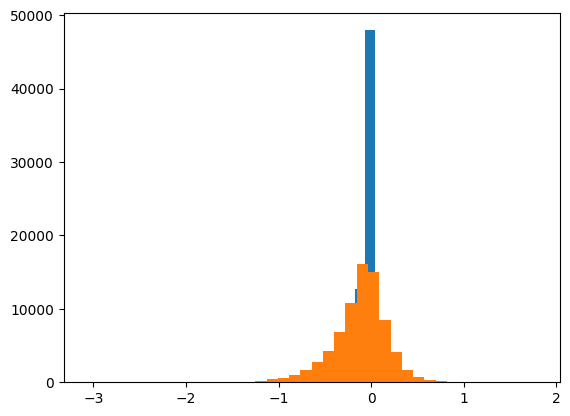

In [58]:
plt.hist(rescat['F090W'], bins=40);
plt.hist(rescat['F300M'], bins=40);

In [61]:
rescat[col].isna()

0         True
1        False
2        False
3         True
4         True
         ...  
91725     True
91726     True
91727     True
91728     True
91729    False
Name: F090W, Length: 91730, dtype: bool

F090W 0.14456596780929232
F115W 0.05895212752238384
F150W 0.08403234607025077
F164N 0.20189610374694883
F187N 0.2994384406714146
F200W 0.12966581056895216
F212N 0.22180372445586222
F277W 0.05549561509621173
F300M 0.2962427503082559
F335M 0.16361504066221172
F356W 0.10613075410845012
F360M 0.1577731035236386
F405N 0.4922858583041218
F444W 0.22765014661379998


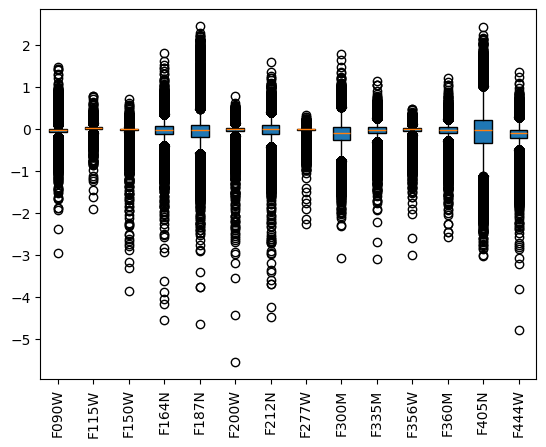

In [67]:
fig, ax = plt.subplots()
resvals = []
for col in rescat.columns:
    nanmask = rescat[col].isna()
    resvals.append(rescat[col][~nanmask].values)
    print(col, np.std(rescat[col][~nanmask].values, ddof=1))
labels = sedfit.cols['flts']

bplot = ax.boxplot(resvals,
                   patch_artist=True,  # fill with color
                   tick_labels=labels)
ax.set_xticklabels(labels=labels, rotation = 90);

In [169]:
rescat.to_csv('data/dolphot/ngc5643/rescat.csv', index=False)

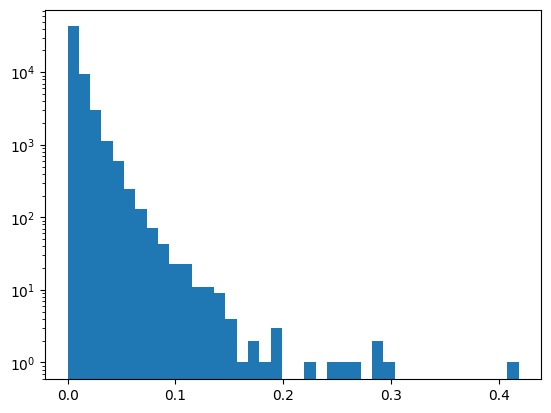

In [212]:
plt.hist(rsgcat['chimin'], bins=40);
plt.yscale('log')

In [213]:
np.median(rsgcat['chimin']) + 3*np.std(rsgcat['chimin'], ddof=1)

np.float64(0.03962608642263024)

In [214]:
(rsgcat['chimin'] > 0.01).sum()

np.int64(15784)

In [28]:
tm = (rsgcat['teff'] <= 3300) | (rsgcat['teff'] >= 4700) | (rsgcat['chimin'] > 0.03)
tm.sum()

np.int64(0)

In [254]:
rsgcat[~tm]

,index,X,Y,SNR,Sharpness,Crowding,Type,F090W_mag,F115W_mag,F150W_mag,...,F356W_err,F360M_err,F405N_err,F444W_err,chimin,teff,tdust,tau,av,lum
225108,225108,1130.77,77.35,2242.1,-0.023,0.116,1,22.687,21.561,21.014,...,0.001,0.003,0.010,0.002,0.005968,3800.0,1000.0,3.0000,1.50,380373.116181
225109,225109,1189.71,80.49,2125.6,-0.145,0.142,1,21.186,20.767,20.550,...,0.001,0.003,0.014,0.004,0.002812,4200.0,1300.0,1.4030,0.00,384282.663157
225112,225112,836.30,385.61,2312.6,-0.093,0.122,1,21.429,20.827,20.491,...,0.001,0.003,0.014,0.004,0.002547,3600.0,1000.0,1.2040,0.00,346940.135095
225121,225121,1546.46,496.67,1973.8,-0.021,0.018,1,21.961,21.208,20.893,...,0.001,0.004,0.016,0.005,0.008379,3400.0,800.0,1.1045,0.00,235208.669057
225125,225125,152.35,898.11,1973.0,-0.046,0.097,1,21.765,21.298,21.112,...,0.001,0.004,0.013,0.004,0.005985,4550.0,1100.0,1.4030,0.75,325702.084222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1503557,1503557,2523.68,1173.51,111.1,-0.035,0.630,1,26.051,25.688,25.346,...,0.041,0.173,0.683,0.204,0.009758,4100.0,1500.0,0.1095,0.75,4805.842589
1506323,1506323,2194.47,518.21,103.8,-0.053,0.717,1,26.176,25.872,25.538,...,0.040,0.207,1.095,0.333,0.021029,4000.0,900.0,0.8060,0.00,3328.460694
1506607,1506607,2098.01,13.71,100.7,-0.131,0.570,1,26.108,25.725,25.506,...,0.062,0.303,0.904,9.999,0.005579,4000.0,500.0,0.0100,0.00,3420.683504
1507260,1507260,2532.17,386.17,96.4,-0.046,0.706,1,26.189,25.736,25.460,...,0.040,0.216,9.999,0.355,0.025018,4100.0,1000.0,0.1095,0.75,4062.348193


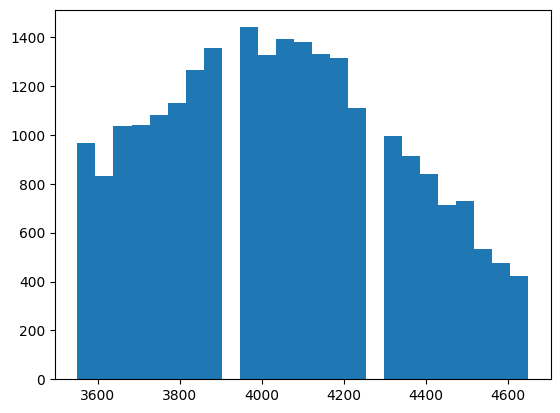

In [249]:
plt.hist(rsgcat[~tm]['teff'], bins=25);

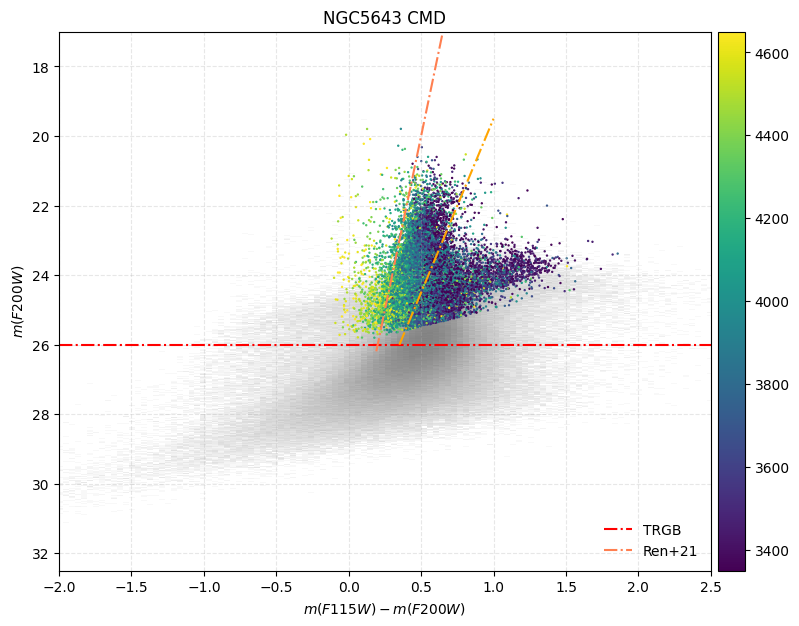

In [18]:
fig, ax = plt.subplots(1, 1, figsize = (10, 7))
f1, f2 = 'F115W', 'F200W'

cl, m = cat[f1+'_mag'] - cat[f2+'_mag'], cat[f2+'_mag']
rsg_cl, rsg_m = rsgcat[f1+'_mag'] - rsgcat[f2+'_mag'], rsgcat[f2+'_mag']

ax.hist2d(cl, m, bins = 4000, norm = 'log', cmap = 'Grays')
sc = ax.scatter(rsg_cl, rsg_m, c=rsgcat['teff'], cmap = 'viridis', s=.5)

ax.axhline(26, color = 'red', label='TRGB', linestyle = '-.')
ax.plot(np.linspace(0.1905, 1, 100), lin(np.linspace(0.1905, 1, 100), -20.0, 33.0-3), linestyle='-.', color = 'coral', label = 'Ren+21')
ax.plot(np.linspace(0.35, 1, 100), lin(np.linspace(0.35, 1, 100), -10.0, 25+4.5), linestyle='-.', color = 'orange')

cbar = fig.colorbar(sc, ax = ax, pad = 0.009)
ax.set_xlabel(rf'$m({f1}) - m({f2})$')
ax.set_ylabel(rf'$m({f2})$')
ax.set_title('NGC5643 CMD')

ax.legend(loc = 'lower right', framealpha = 0)
ax.tick_params(axis='both', which='major')
ax.tick_params(axis='both', which='minor')
cbar.ax.tick_params() 
ax.grid(alpha = 0.3, linestyle = '--')
ax.set_xlim(-2, 2.5)
# ax.set_xlim(0, 1)
ax.set_ylim(32.5, 17)
# ax.set_ylim(26, 20)
plt.show()

In [94]:
sedfit = parallel_sed_fit(gal='ngc5643', 
                          photfile_path='data/dolphot/ngc5643', 
                          dm=30.57, 
                          dmerr=0.06, 
                          z=-0.25, 
                          trgb=('F090W', 26.20), 
                          comp='grf',
                          keep_narrow=False, 
                          ncores=1)
rsgcat = sedfit.apply_initial_cuts()

DOLPHOT catalog contains 1804516 objects after photometry cuts
DOLPHOT catalog contains 1804516 objects after photometry cuts
DOLPHOT catalog contains 1804516 objects after photometry cuts
DOLPHOT catalog contains 1804516 objects after photometry cuts
DOLPHOT catalog contains 1804516 objects after photometry cuts
DOLPHOT catalog contains 1804516 objects after photometry cuts
DOLPHOT catalog contains 1804516 objects after photometry cuts
rsg_sedfit [@ Tue, 02 Sep 2025 01:00:53] [l 104] - INFO - DOLPHOT catalog contains 1804516 objects after photometry cuts
Applying ndet cuts
Applying ndet cuts
Applying ndet cuts
Applying ndet cuts
Applying ndet cuts
Applying ndet cuts
Applying ndet cuts
rsg_sedfit [@ Tue, 02 Sep 2025 01:00:53] [l 12] - INFO - Applying ndet cuts
RSG catalog contains 88267 objects after ndet cuts
RSG catalog contains 88267 objects after ndet cuts
RSG catalog contains 88267 objects after ndet cuts
RSG catalog contains 88267 objects after ndet cuts
RSG catalog contains 8826

941627 146410


RSG catalog contains 69259 objects after color cuts
RSG catalog contains 69259 objects after color cuts
RSG catalog contains 69259 objects after color cuts
RSG catalog contains 69259 objects after color cuts
RSG catalog contains 69259 objects after color cuts
RSG catalog contains 69259 objects after color cuts
RSG catalog contains 69259 objects after color cuts
rsg_sedfit [@ Tue, 02 Sep 2025 01:02:16] [l 241] - INFO - RSG catalog contains 69259 objects after color cuts
Applying chisq cuts
Applying chisq cuts
Applying chisq cuts
Applying chisq cuts
Applying chisq cuts
Applying chisq cuts
Applying chisq cuts
rsg_sedfit [@ Tue, 02 Sep 2025 01:02:16] [l 4] - INFO - Applying chisq cuts
100%|██████████| 69259/69259 [13:07<00:00, 87.99it/s] 
RSG catalog contains 69259 objects after chisq cuts
RSG catalog contains 69259 objects after chisq cuts
RSG catalog contains 69259 objects after chisq cuts
RSG catalog contains 69259 objects after chisq cuts
RSG catalog contains 69259 objects after chisq 

In [95]:
df_sil = pd.read_csv('data/dolphot/ngc5643/ngc5643_sil_rsgcat.csv')
df_grf = pd.read_csv('data/dolphot/ngc5643/ngc5643_grf_rsgcat.csv')
df_sil.set_index('index', inplace=True)
df_grf.set_index('index', inplace=True)

In [96]:
grfm = np.array([i in df_sil.index for i in df_grf.index])
silm = np.array([i in df_grf.index for i in df_sil.index])

In [97]:
df1 = df_sil[~silm]
df2 = df_grf[~grfm]
df3 = df_sil[silm][df_sil[silm]['chimin'].values < df_grf[grfm]['chimin'].values]
df4 = df_grf[grfm][df_sil[silm]['chimin'].values > df_grf[grfm]['chimin'].values]
rsgcat = pd.concat([df1, df2, df3, df4])

In [98]:
chi_all = rsgcat['chimin'].values

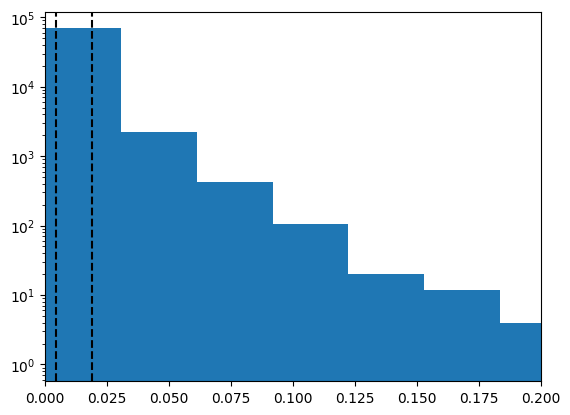

In [114]:
plt.hist(chi_all, bins=100)
plt.yscale('log')
plt.xlim(0.0, 0.2)
sig = np.std(chi_all, ddof=1)
me = np.median(chi_all)
plt.axvline(sig, ls='--', color='black')
plt.axvline(me, ls='--', color='black')

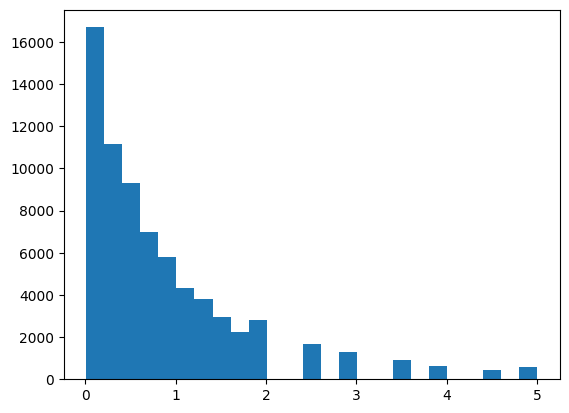

In [245]:
plt.hist(rsgcat['tau_chisq'], bins = 25);

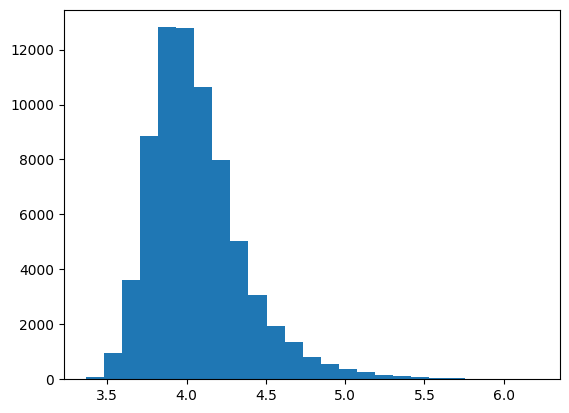

In [130]:
plt.hist(np.log10(rsgcat['lum_chisq']), bins = 25);

In [ ]:
lm = np.log10(rsgcat['lum_chisq'].values) > 4.5
tm = rsgcat['tau_chisq'].values > 1

In [132]:
cm = rsgcat['chimin'] < 0.008
tm = (rsgcat['teff_chisq'] > 3300) & (rsgcat['teff_chisq'] < 4700)
tum = rsgcat['tau_chisq'].values > 1
lm = np.log10(rsgcat['lum_chisq'].values) > 4.5

In [135]:
(((rsgcat['teff_chisq'] > 2900) & (rsgcat['teff_chisq'] < 4700)) & cm).sum()

np.int64(45441)

In [136]:
(cm & (tm | tum | lm)).sum()

np.int64(35055)

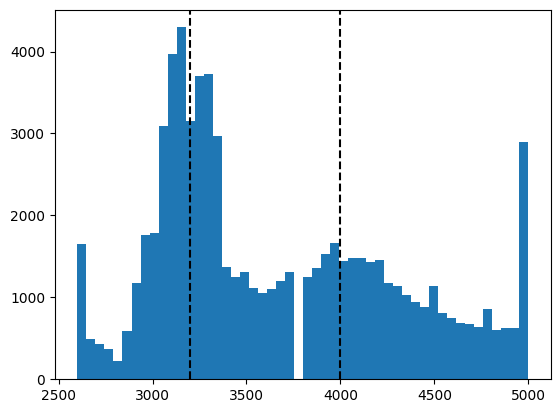

In [143]:
plt.hist(rsgcat['teff_chisq'], bins=50);
plt.axvline(3200, ls='--', color='black')
plt.axvline(4000, ls='--', color='black')

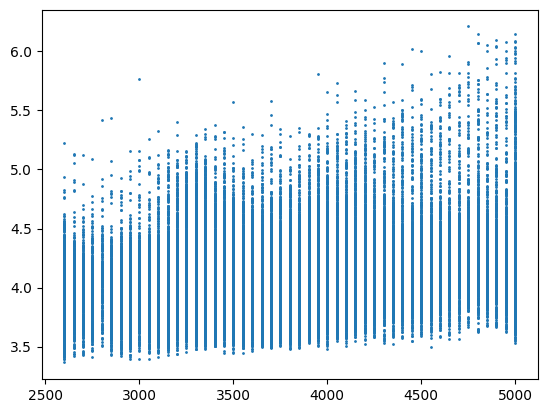

In [18]:
plt.scatter(rsgcat['teff_chisq'], np.log10(rsgcat['lum_chisq']), s=1);

### parallel mcmc

In [3]:
%reload_ext autoreload
%autoreload 2
from mc_parallel import parallel_sed_fit

In [4]:
#create grf modeldf
sedfit = parallel_sed_fit(gal='ngc5643', 
                          photfile_path='data/dolphot/ngc5643', 
                          dm=30.57, 
                          dmerr=0.06, 
                          z=-0.25, 
                          trgb=('F090W', 26.20),
                          comp='grf',
                          keep_narrow=False, 
                          ncores=1)
sedfit.create_modeldf()

DOLPHOT catalog contains 1804516 objects after photometry cuts
rsg_sedfit [@ Mon, 01 Sep 2025 15:34:05] [l 104] - INFO - DOLPHOT catalog contains 1804516 objects after photometry cuts
Creating modeldf: data/dolphot/ngc5643/ngc5643_grf_modeldf.csv
rsg_sedfit [@ Mon, 01 Sep 2025 15:34:05] [l 249] - INFO - Creating modeldf: data/dolphot/ngc5643/ngc5643_grf_modeldf.csv
100%|██████████| 49/49 [51:20<00:00, 62.86s/it]


,Teff,Tdust,Tau,Av,F070W,F090W,F115W,F140M,F150W,F150W2,...,F356W,F360M,F405N,F410M,F430M,F444W,F460M,F466N,F470N,F480M
0,2600,200,0.01,0.0,31.065818,28.365387,26.784437,26.869419,26.528309,26.54447,...,27.131012,27.045596,27.274244,27.23272,27.497715,27.474512,27.650496,27.69212,27.630092,27.831161
1,2600,200,0.01,0.25,31.236566,28.479149,26.863442,26.927916,26.579659,26.593368,...,27.143962,27.058236,27.284824,27.243306,27.507419,27.484194,27.659046,27.700582,27.638408,27.839214
2,2600,200,0.01,0.5,31.407216,28.592773,26.942383,26.986405,26.630979,26.641966,...,27.156909,27.070876,27.295404,27.253892,27.517122,27.493875,27.667595,27.709044,27.646724,27.847267
3,2600,200,0.01,0.75,31.577764,28.706251,27.021257,27.044885,26.682269,26.690248,...,27.169855,27.083516,27.305984,27.264477,27.526825,27.503554,27.676144,27.717506,27.65504,27.85532
4,2600,200,0.01,1.0,31.748214,28.819588,27.100065,27.103356,26.733529,26.738227,...,27.182799,27.096155,27.316564,27.275062,27.536529,27.513233,27.684694,27.725968,27.663356,27.863373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190507,5000,1700,5.0,1.0,31.675538,30.169197,28.805278,27.849281,27.5657,27.21681,...,26.113689,26.113033,26.170231,26.177225,26.218829,26.249525,26.308005,26.324726,26.321954,26.360212
190508,5000,1700,5.0,1.5,32.03118,30.400421,28.961021,27.965219,27.668807,27.294222,...,26.140091,26.13846,26.191389,26.198219,26.238222,26.268478,26.325103,26.341659,26.338579,26.376272
190509,5000,1700,5.0,2.0,32.386822,30.631646,29.116764,28.081157,27.771915,27.371635,...,26.166493,26.163887,26.212546,26.219213,26.257615,26.287432,26.3422,26.358593,26.355205,26.392331
190510,5000,1700,5.0,2.5,32.742464,30.86287,29.272508,28.197095,27.875022,27.449048,...,26.192895,26.189315,26.233704,26.240207,26.277007,26.306385,26.359297,26.375526,26.371831,26.40839


In [ ]:
#test rsgcat with  10-50 entries
rsgcat = pd.read_csv('data/dolphot/ngc5643/rsgcat_chimin.csv')
testcat = rsgcat[:50]
testcat.reset_index(inplace=True, drop=True)
testcat.loc[:, 'index'] = testcat.index

In [ ]:
#test parallelization
sedfit = parallel_sed_fit(gal='ngc5643', 
                          photfile_path='data/dolphot/ngc5643', 
                          dm=30.57, 
                          dmerr=0.06, 
                          z=-0.25, 
                          trgb=('F090W', 26.20), 
                          keep_narrow=False, 
                          ncores=8,
                          rsgcat=testcat)

In [70]:
sedfit.run_sed_fit()

rsg_sedfit [@ Wed, 27 Aug 2025 14:43:06] [l 16] - INFO - Starting MCMC
Starting MCMC


[Wed, 27 Aug 2025 14:43:07] Running MCMC on index 0
[Wed, 27 Aug 2025 14:43:08] Running MCMC on index 1
[Wed, 27 Aug 2025 14:43:09] Running MCMC on index 2
[Wed, 27 Aug 2025 14:43:09] Running MCMC on index 3
[Wed, 27 Aug 2025 14:43:10] Running MCMC on index 4
[Wed, 27 Aug 2025 14:43:10] Running MCMC on index 5
[Wed, 27 Aug 2025 14:43:11] Running MCMC on index 6
[Wed, 27 Aug 2025 14:43:12] Running MCMC on index 7
[Wed, 27 Aug 2025 14:43:13] Running MCMC on index 8
[Wed, 27 Aug 2025 14:43:14] Running MCMC on index 9
[Wed, 27 Aug 2025 14:43:15] Running MCMC on index 10
[Wed, 27 Aug 2025 14:43:16] Running MCMC on index 11
[Wed, 27 Aug 2025 14:43:17] Running MCMC on index 12
[Wed, 27 Aug 2025 14:43:18] Running MCMC on index 13
[Wed, 27 Aug 2025 14:43:19] Running MCMC on index 14
[Wed, 27 Aug 2025 14:43:19] Running MCMC on index 15
[Wed, 27 Aug 2025 14:43:36] Running MCMC on index 16
[Wed, 27 Aug 2025 14:44:14] Running MCMC on index 17
[Wed, 27 Aug 2025 14:44:18] Running MCMC on index 18
[We

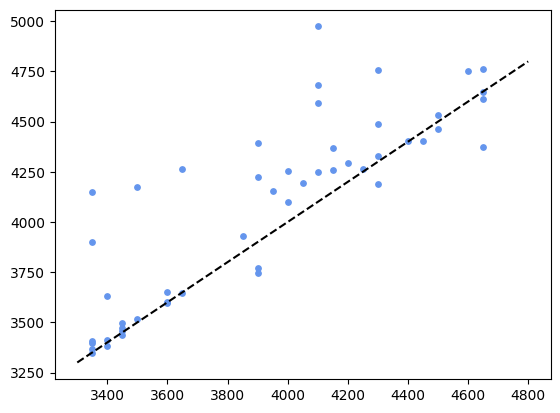

In [ ]:
#compare mcmc teff and chimin teff
plt.scatter(sedfit.rsgcat['teff'], sedfit.rsgcat['temperature_best'], marker='o', color='cornflowerblue', s=15)
plt.plot([3300, 4800], [3300, 4800], ls='--', color='black');